In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [ ]:
df=pd.read_csv('/content/Food_Delivery_Time_Prediction.csv')

In [ ]:





df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


Phase 1 - Data Preprocessing and Feature Engineering
Data Import and Cleaning:


In [ ]:

Le=LabelEncoder()
df['Weather_Conditions']=Le.fit_transform(df['Weather_Conditions'])
df['Traffic_Conditions']=Le.fit_transform(df['Traffic_Conditions'])
df['Vehicle_Type']=Le.fit_transform(df['Vehicle_Type'])


In [ ]:



from sklearn.preprocessing import StandardScaler

Feature Engineering:

In [ ]:
!pip install haversine

from haversine import haversine

# Extract latitude and longitude from string format
df[['Customer_Latitude', 'Customer_Longitude']] = df['Customer_Location'].str.replace('(', '').str.replace(')', '').str.split(', ', expand=True).astype(float)
df[['Restaurant_Latitude', 'Restaurant_Longitude']] = df['Restaurant_Location'].str.replace('(', '').str.replace(')', '').str.split(', ', expand=True).astype(float)

df['Distance_km'] = df.apply(lambda row: haversine(
    (row['Customer_Latitude'], row['Customer_Longitude']),
    (row['Restaurant_Latitude'], row['Restaurant_Longitude'])
), axis=1)

In [ ]:

df[['Customer_Latitude','Restaurant_Latitude','Distance_km']].head()

,Customer_Latitude,Restaurant_Latitude,Distance_km
0,17.030479,12.358515,775.652269
1,15.398319,14.174874,1042.387037
2,15.687342,19.594748,476.221364
3,20.415599,16.915906,389.913167
4,14.786904,15.206038,806.507000


In [ ]:
df['Order_Time_Morning'] = (df['Order_Time'] == 'Morning').astype(int)
df['Order_Time_Afternoon'] = (df['Order_Time'] == 'Afternoon').astype(int)
df['Order_Time_Evening'] = (df['Order_Time'] == 'Evening').astype(int)
df['Order_Time_Night'] = (df['Order_Time'] == 'Night').astype(int)

df['Rush_Hour'] = ( (df['Order_Time_Morning'] == 1) | (df['Order_Time_Evening'] == 1) | (df['Order_Time_Night'] == 1) ).astype(int)

In [ ]:

df['Non_Rush_Hour']=(df['Rush_Hour']==0).astype(int)

In [ ]:

print(df.columns)

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'Customer_Latitude', 'Customer_Longitude',
       'Restaurant_Latitude', 'Restaurant_Longitude', 'Distance_km',
       'Order_Time_Morning', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Night', 'Rush_Hour', 'Non_Rush_Hour'],
      dtype='object')


Phase 2 - Clustering using K-Means and Hierarchical Clustering
K-Means Clustering


In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,...,Customer_Longitude,Restaurant_Latitude,Restaurant_Longitude,Distance_km,Order_Time_Morning,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Night,Rush_Hour,Non_Rush_Hour
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,Medium,Afternoon,2,...,79.743077,12.358515,85.100083,775.652269,0,1,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,Low,Night,2,...,86.639122,14.174874,77.025606,1042.387037,0,0,0,1,1,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,High,Night,1,...,83.888808,19.594748,82.048482,476.221364,0,0,0,1,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,Medium,Evening,1,...,78.046984,16.915906,78.278698,389.913167,0,0,1,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,Low,Night,1,...,78.706532,15.206038,86.203182,806.507000,0,0,0,1,1,0


In [ ]:
intertia=[]
for k in range(2,10):
  kmeans=KMeans(n_clusters=k)
  kmeans.fit(df[['Distance','Delivery_Time']])
  intertia.append(kmeans.inertia_)

In [ ]:

!pip install haversine
from sklearn.preprocessing import StandardScaler, LabelEncoder
from haversine import haversine

# Re-apply Label Encoding for categorical features
Le = LabelEncoder()
df['Weather_Conditions'] = Le.fit_transform(df['Weather_Conditions'])
df['Traffic_Conditions'] = Le.fit_transform(df['Traffic_Conditions'])

# Re-calculate Distance_km
# Extract latitude and longitude from string format
df[['Customer_Latitude', 'Customer_Longitude']] = df['Customer_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False).str.split(', ', expand=True).astype(float)
df[['Restaurant_Latitude', 'Restaurant_Longitude']] = df['Restaurant_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False).str.split(', ', expand=True).astype(float)

df['Distance_km'] = df.apply(lambda row: haversine(
    (row['Customer_Latitude'], row['Customer_Longitude']),
    (row['Restaurant_Latitude'], row['Restaurant_Longitude'])
), axis=1)

# Now apply StandardScaler to the selected features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Delivery_Time', 'Distance_km', 'Traffic_Conditions', 'Weather_Conditions']])

In [ ]:
from sklearn.cluster import KMeans

intertia=[]
for k in range(2,10):
  km = KMeans(n_clusters=k)
  km.fit(scaled_features)
  intertia.append(km.inertia_)

Text(0, 0.5, 'Intertia')

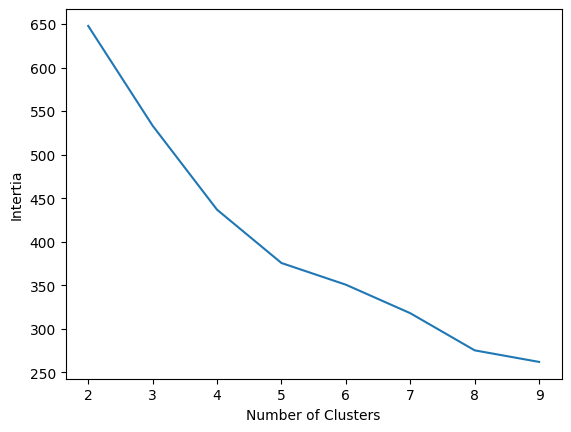

In [ ]:
plt.plot(range(2,10),intertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Intertia')

In [ ]:
from sklearn.cluster import KMeans

kmeans_model=KMeans(n_clusters=4,random_state=42)
df['cluster']= kmeans_model.fit_predict(scaled_features)

Scatter plot: Distance vs Delivery time

Text(0, 0.5, 'Delivery Time')

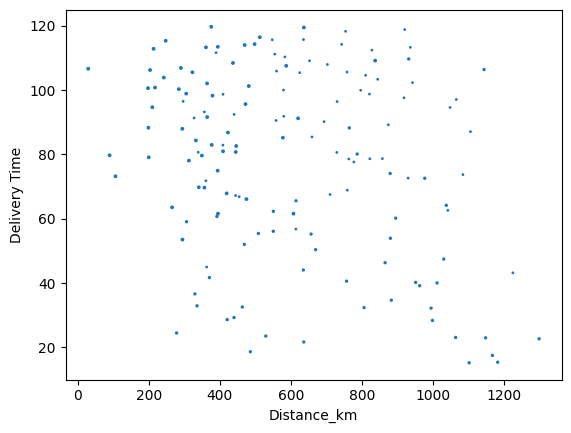

In [ ]:
plt.scatter(df['Distance_km'],df['Delivery_Time'],df['cluster'])
plt.xlabel('Distance_km')
plt.ylabel('Delivery Time')

scatter plot : traffic vs delivery time

Text(0, 0.5, 'Delivery')

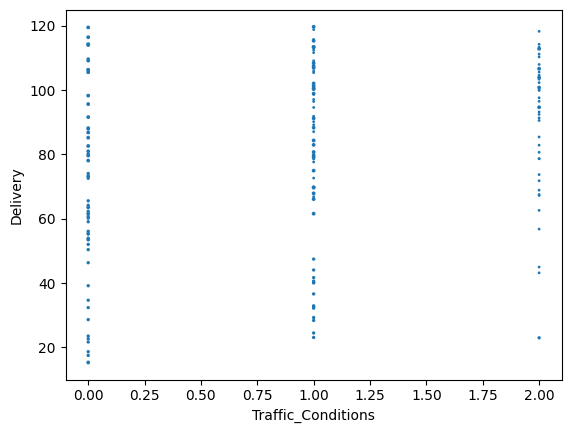

In [ ]:
plt.scatter(df['Traffic_Conditions'],df['Delivery_Time'],df['cluster'])
plt.xlabel('Traffic_Conditions')
plt.ylabel('Delivery')

weather vs delivery time

Text(0, 0.5, 'Delivery Time')

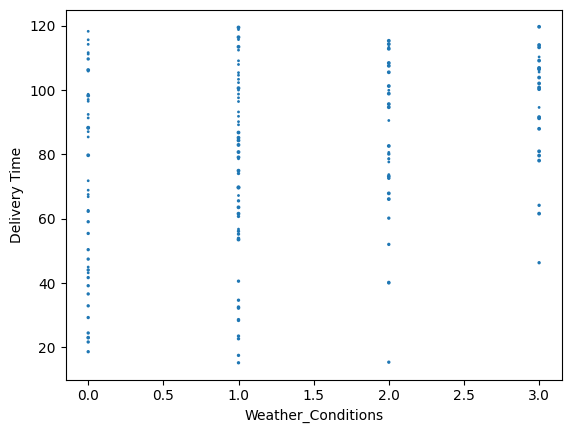

In [ ]:

plt.scatter(df['Weather_Conditions'],df['Delivery_Time'],df['cluster'])
plt.xlabel('Weather_Conditions')
plt.ylabel('Delivery Time')

customer vs resturtant location cluster

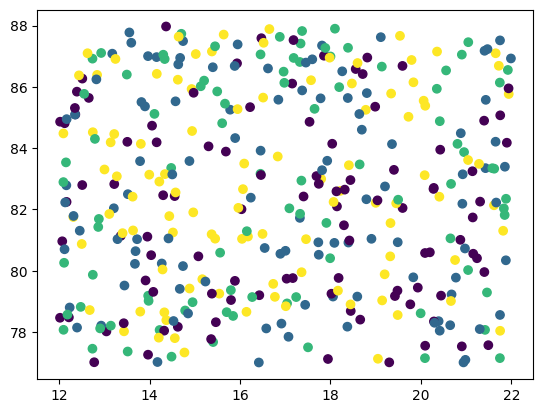

In [ ]:


plt.scatter(df['Restaurant_Latitude'], df['Restaurant_Longitude'], c=df['cluster'])
plt.scatter(df['Customer_Latitude'], df['Customer_Longitude'], c=df['cluster'])

Hierarchical clustering

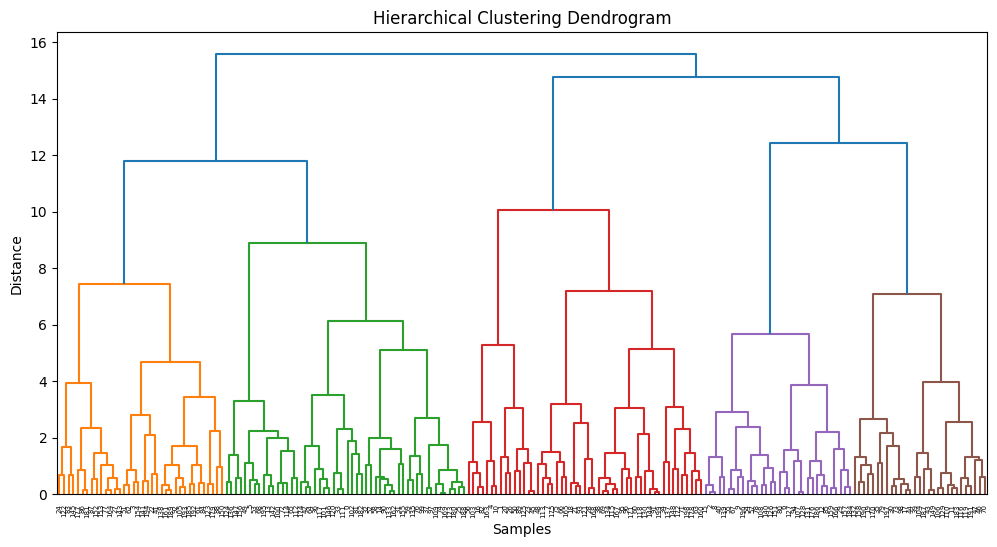

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linkage_matrix = linkage(scaled_features, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
import plotly.graph_objs as go
import plotly.offline as py

trace1 = go.Scatter3d(
    x=df['Delivery_Time'],
    y=df['Distance_km'],
    z=df['Traffic_Conditions'],
    mode='markers',
    marker=dict(
        color=df['cluster'],
        size=10,
        line=dict(
            color=df['cluster'],
            width=12
        ),
        opacity=0.8
    )
)

data = [trace1]
layout = go.Layout(
    title='3D Scatter Plot',
    scene=dict(
        xaxis=dict(title='Delivery Time'),
        yaxis=dict(title='Distance'),
        zaxis=dict(title='Traffic Conditions')
    )
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig)

neural networks for prediction

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

if 'Order_Priority' in df.columns:
    Le_priority = LabelEncoder()
    df['Order_Priority_encoded'] = Le_priority.fit_transform(df['Order_Priority'])

feature_columns = [
    'Distance_km',
    'Traffic_Conditions',
    'Weather_Conditions',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount',
    'Order_Time_Morning',
    'Order_Time_Afternoon',
    'Order_Time_Evening',
    'Order_Time_Night',
    'Rush_Hour',
    'Non_Rush_Hour'
]

if 'Order_Priority_encoded' in df.columns:
    feature_columns.append('Order_Priority_encoded')

X = df[feature_columns]


median_delivery_time = df['Delivery_Time'].median()
y = (df['Delivery_Time'] > median_delivery_time).astype(int)

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale features (very important)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Build a simple neural network
model = Sequential()
model.add(Dense(20, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # output layer

# 4. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32)

# 6. Test the model
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

# 7. Predict
predictions = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4266 - loss: 0.7594
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4275 - loss: 0.7450
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4266 - loss: 0.7356
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4436 - loss: 0.7295
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5451 - loss: 0.6876 
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4686 - loss: 0.7186
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4971 - loss: 0.7204
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5448 - loss: 0.6832 
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5599 - loss: 0.6805
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5411 - loss: 0.6883
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5412 - loss: 0.6895 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5519 - loss: 0.6763

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
y_pred = (predictions > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.45
Precision: 0.47058823529411764
Recall   : 0.38095238095238093
F1 Score : 0.42105263157894735


In [ ]:
def build_model(layers, neurons, activation, lr, input_dim):
    model = Sequential()

    # input + first hidden layer
    model.add(Dense(neurons, activation=activation, input_dim=input_dim))

    # extra hidden layers
    for i in range(layers - 1):
        model.add(Dense(neurons, activation=activation))

    # output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
layers_list = [1, 2]
neurons_list = [16, 32]
activations = ['relu']
learning_rates = [0.001, 0.01]


In [ ]:
best_acc = 0
best_model = None

for layers in layers_list:
    for neurons in neurons_list:
        for act in activations:
            for lr in learning_rates:

                model = build_model(
                    layers, neurons, act, lr,
                    input_dim=X_train.shape[1]
                )

                model.fit(X_train, y_train, epochs=10, verbose=0)

                _, acc = model.evaluate(X_test, y_test, verbose=0)

                print("Layers:", layers,
                      "Neurons:", neurons,
                      "LR:", lr,
                      "Acc:", acc)

                if acc > best_acc:
                    best_acc = acc
                    best_model = model


NameError: name 'X_train' is not defined